# 📊 Análise Operacional de Pedidos e Entregas — Olist

## 🎯 Objetivo do Projeto

Este projeto tem como objetivo analisar dados operacionais de um marketplace brasileiro, utilizando o dataset público da Olist.

A análise simula problemas reais de uma operação semelhante a empresas de delivery e e-commerce, como:

- Identificação de horários de pico de pedidos
- Análise do tempo médio de entrega por região
- Detecção de entregas com atrasos extremos usando Z-score
- Relação entre valor do frete e distância estimada entre vendedor e cliente

## 🧠 Problema de Negócio

Em plataformas de marketplace e delivery, entender padrões operacionais é essencial para melhorar logística, reduzir atrasos e aumentar a satisfação do cliente.

Este projeto busca responder perguntas como:

- Em quais horários os clientes mais realizam pedidos?
- Quais estados apresentam maior tempo médio de entrega?
- Existem entregas com atrasos muito fora do padrão?
- O valor do frete acompanha a distância entre vendedor e cliente?

## 🛠️ Ferramentas Utilizadas

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy

# 1. Importação das Bibliotecas

Nesta etapa, serão importadas as bibliotecas utilizadas para manipulação dos dados, visualização gráfica, estatística e cálculo de distância geográfica.

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# cria pasta de imagens automaticamente
os.makedirs('images', exist_ok=True)

def salvar_grafico(nome):
    plt.savefig(f'images/{nome}.png', dpi=300, bbox_inches='tight')
    print(f'✅ Gráfico salvo em images/{nome}.png')

from scipy.stats import zscore
from math import radians, sin, cos, sqrt, atan2

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# 2. Carregamento dos Dados

Os arquivos CSV do dataset da Olist foram carregados diretamente no Google Colab.

Neste projeto, serão utilizadas as seguintes tabelas:

- Pedidos
- Clientes
- Itens do pedido
- Vendedores
- Geolocalização

In [79]:
import pandas as pd

# 1. Link base correto apontando para o servidor de dados brutos do seu GitHub
url_base = 'https://raw.githubusercontent.com/realcoli/olist-operational-analysis/main/data/'

# 2. Lendo os 4 arquivos CSV diretamente do seu repositório
orders = pd.read_csv(url_base + 'olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

customers = pd.read_csv(url_base + 'olist_customers_dataset.csv')
sellers = pd.read_csv(url_base + 'olist_sellers_dataset.csv')
items = pd.read_csv(url_base + 'olist_order_items_dataset.csv')

# Caso você tenha o arquivo de geolocalização lá, descomente a linha abaixo:
# geolocation = pd.read_csv(url_base + 'olist_geolocation_dataset.csv', low_memory=False, encoding='latin-1', on_bad_lines='skip')

print("Todos os 4 arquivos CSV foram carregados com sucesso diretamente do GitHub!")

Todos os 4 arquivos CSV foram carregados com sucesso diretamente do GitHub!


# 3. Visualização Inicial das Tabelas

Antes de iniciar a análise, é importante observar a estrutura inicial dos dados para entender quais colunas estão disponíveis em cada tabela.

In [80]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [81]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [82]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


# 4. Entendimento e Qualidade dos Dados

Nesta etapa, será feita uma verificação inicial dos tipos de dados, valores ausentes e status dos pedidos.

Esse processo é importante para evitar análises distorcidas por dados incompletos ou pedidos que não foram entregues.

In [83]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [84]:
orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [85]:
orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


# 5. Tratamento dos Dados

Para analisar tempo de entrega e eficiência logística, serão considerados apenas pedidos com status `delivered`.

Pedidos cancelados, indisponíveis ou sem data de entrega foram removidos para evitar distorções nos cálculos.

In [86]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

delivered_orders = delivered_orders.dropna(subset=[
    'order_purchase_timestamp',
    'order_delivered_customer_date'
])

print('Total de pedidos entregues:', delivered_orders.shape[0])

Total de pedidos entregues: 96470


# 6. Análise 1 — Horários de Pico de Pedidos

O objetivo desta análise é identificar os horários do dia com maior volume de pedidos.

Essa informação é relevante para empresas digitais porque ajuda no planejamento de campanhas, atendimento, suporte e capacidade operacional.

In [87]:
delivered_orders['order_hour'] = delivered_orders['order_purchase_timestamp'].dt.hour

orders_by_hour = (
    delivered_orders
    .groupby('order_hour')['order_id']
    .count()
    .reset_index()
)

orders_by_hour.columns = ['hour', 'total_orders']

orders_by_hour

,hour,total_orders
0,0,2321
1,1,1133
2,2,496
3,3,259
4,4,203
5,5,182
6,6,477
7,7,1199
8,8,2907
9,9,4647


✅ Gráfico salvo em images/Volume_de_Pedidos_por_Hora_do_Dia.png


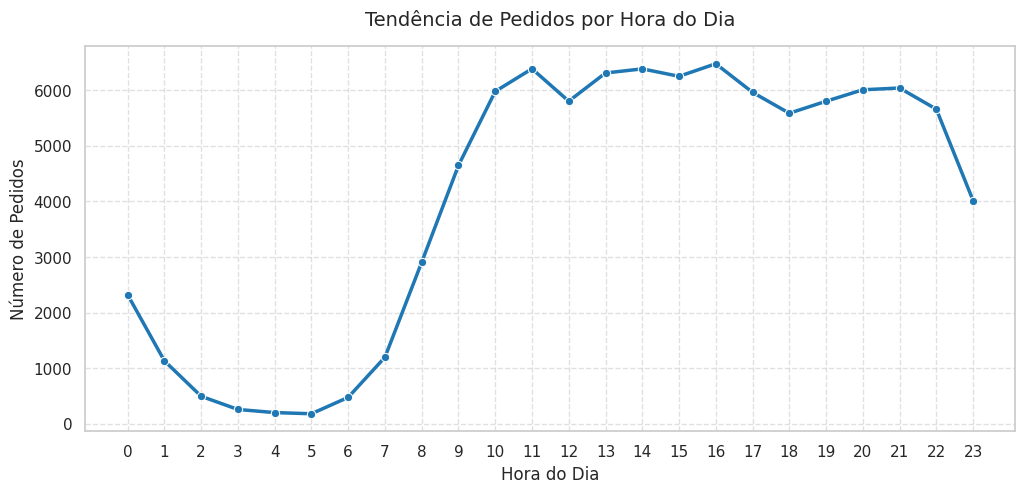

In [88]:
# Definindo a figura
plt.figure(figsize=(12, 5))

# Alterado para lineplot para destacar a tendência contínua do tempo
sns.lineplot(data=orders_by_hour, x='hour', y='total_orders', marker='o', color='#1f77b4', linewidth=2.5)

# Títulos e rótulos
plt.title('Tendência de Pedidos por Hora do Dia', fontsize=14, pad=15)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Número de Pedidos', fontsize=12)

# Ajuste fino dos eixos
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

# Salvando e exibindo
salvar_grafico('Volume_de_Pedidos_por_Hora_do_Dia')
plt.show()


## 💡 Insight — Horários de Pico

O volume de pedidos apresenta crescimento progressivo ao longo do dia, com forte concentração entre 10h e 22h, atingindo seu pico no período da tarde e início da noite.

Durante a madrugada e início da manhã (0h–6h), a demanda é significativamente menor, indicando baixo uso da plataforma fora do horário comercial.

Esse padrão sugere um comportamento de consumo concentrado após o início do expediente e ao longo do período ativo do dia, com destaque para momentos de pausa e pós-trabalho.

### 📊 Implicações de Negócio

- Necessidade de maior capacidade operacional entre 10h e 22h
- Oportunidade de campanhas promocionais em horários de menor demanda (madrugada/manhã)
- Possível otimização de escala logística e atendimento com base no pico de pedidos

# 7. Análise 2 — Tempo Médio de Entrega por Estado

Nesta etapa, será calculado o tempo entre a data da compra e a data de entrega ao cliente.

Depois, o resultado será agrupado por estado para identificar diferenças regionais na operação logística.

In [89]:
delivered_orders['delivery_time_days'] = (
    delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']
).dt.days

df_delivery = delivered_orders.merge(customers, on='customer_id', how='left')

delivery_by_state = (
    df_delivery
    .groupby('customer_state')['delivery_time_days']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

delivery_by_state.columns = ['state', 'avg_delivery_days']

delivery_by_state

,state,avg_delivery_days
0,RR,28.975610
1,AP,26.731343
2,AM,25.986207
3,AL,24.040302
4,PA,23.316068
5,MA,21.117155
6,SE,21.029851
7,CE,20.817826
8,AC,20.637500
9,PB,19.953578


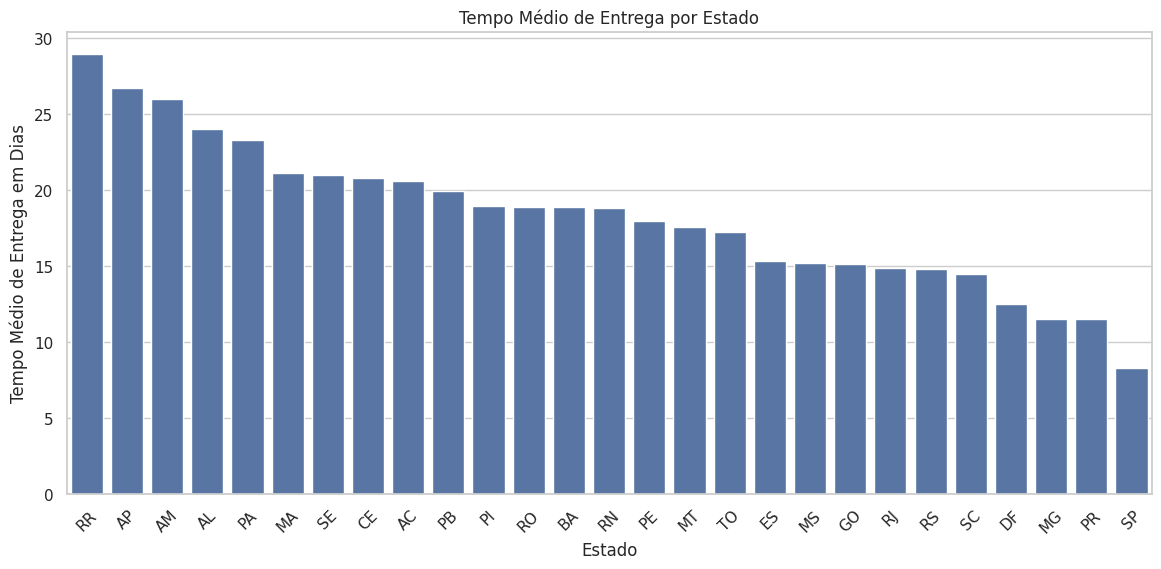

In [90]:
plt.figure(figsize=(14, 6))
sns.barplot(data=delivery_by_state, x='state', y='avg_delivery_days')

plt.title('Tempo Médio de Entrega por Estado')
plt.xlabel('Estado')
plt.ylabel('Tempo Médio de Entrega em Dias')
plt.xticks(rotation=45)
plt.savefig('images/Tempo Médio de Entrega por Estado.png', dpi=300)
plt.show()

## 💡 Insight — Tempo Médio de Entrega por Estado

A análise evidencia uma variação significativa no tempo médio de entrega entre os estados brasileiros.

Estados das regiões Norte e Nordeste tendem a apresentar maiores tempos médios de entrega, enquanto estados do Sudeste e Sul apresentam tempos menores.

Esse comportamento sugere influência direta de fatores como:

- Distância geográfica
- Infraestrutura logística
- Concentração de vendedores e centros de distribuição
- Eficiência da malha de transporte

### 📊 Implicações de Negócio

- Identificação de regiões com maior risco logístico
- Necessidade de otimização de rotas e parceiros logísticos
- Possível investimento em hubs regionais
- Ajuste mais realista de prazos de entrega por localização

# 8. Análise 3 — Identificação de Outliers com Z-score

Nesta etapa, será utilizado o Z-score para identificar entregas com tempo muito acima do padrão da base.

O Z-score mostra quantos desvios padrão um valor está distante da média.

Neste projeto, serão consideradas entregas outliers aquelas com:

`|Z-score| > 3`

Ou seja, entregas com atraso extremamente fora do comportamento esperado.

In [91]:
df_delivery = df_delivery.dropna(subset=['delivery_time_days']).copy()

df_delivery['delivery_zscore'] = zscore(df_delivery['delivery_time_days'])

outliers_delivery = df_delivery[df_delivery['delivery_zscore'].abs() > 3]

print('Total de pedidos analisados:', len(df_delivery))
print('Total de entregas outliers:', len(outliers_delivery))
print('Percentual de outliers:', round(len(outliers_delivery) / len(df_delivery) * 100, 2), '%')

Total de pedidos analisados: 96470
Total de entregas outliers: 1614
Percentual de outliers: 1.67 %


## 💡 Insight — Outliers de Entrega

Foram identificadas entregas com tempo significativamente acima da média da operação, classificadas como outliers estatísticos.

Esses casos representam falhas operacionais e possuem alto impacto na experiência do cliente.

### 📊 Implicações de Negócio

- Monitoramento ativo de atrasos extremos  
- Investigação de causas raiz  
- Redução de impacto negativo na percepção do cliente  

In [92]:
outliers_delivery[['order_id', 'customer_state', 'delivery_time_days', 'delivery_zscore']].sort_values(
    by='delivery_time_days',
    ascending=False
).head(10)

,order_id,customer_state,delivery_time_days,delivery_zscore
19029,ca07593549f1816d26a572e06dc1eab6,ES,209,20.615599
53963,1b3190b2dfa9d789e1f14c05b647a14a,RJ,208,20.510901
59778,440d0d17af552815d15a9e41abe49359,PA,195,19.149834
86459,285ab9426d6982034523a855f55a885e,SE,194,19.045137
37371,0f4519c5f1c541ddec9f21b3bddd533a,PI,194,19.045137
68207,2fb597c2f772eca01b1f5c561bf6cc7b,PI,194,19.045137
11074,47b40429ed8cce3aee9199792275433f,SP,191,18.731045
78961,2fe324febf907e3ea3f2aa9650869fa5,SP,189,18.521650
52862,2d7561026d542c8dbd8f0daeadf67a43,SE,188,18.416952
66712,c27815f7e3dd0b926b58552628481575,MG,187,18.312255


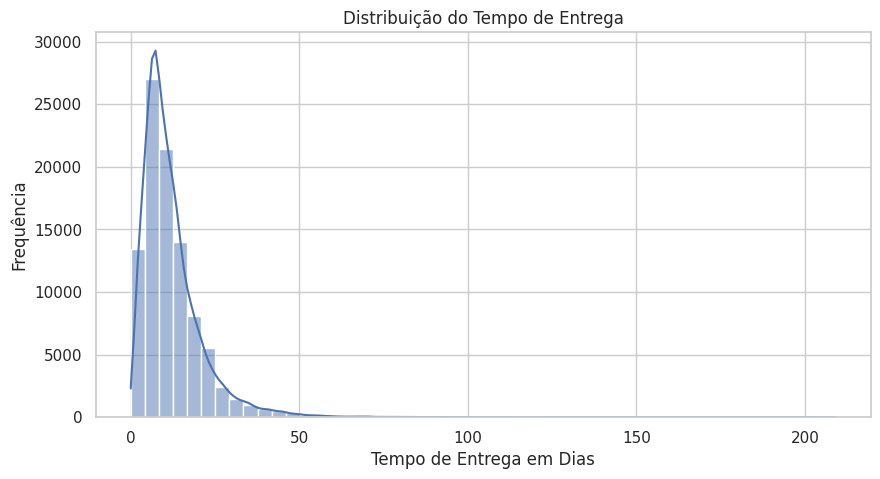

In [93]:
plt.figure(figsize=(10, 5))
sns.histplot(df_delivery['delivery_time_days'], bins=50, kde=True)

plt.title('Distribuição do Tempo de Entrega')
plt.xlabel('Tempo de Entrega em Dias')
plt.ylabel('Frequência')
plt.savefig('images/Distribuição do Tempo de Entrega.png', dpi=300)
plt.show()

## 💡 Insight — Distribuição do Tempo de Entrega

A distribuição do tempo de entrega apresenta forte assimetria à direita, indicando que a maioria dos pedidos é entregue em um intervalo relativamente curto, enquanto poucos casos apresentam atrasos significativamente elevados.

A maior concentração de entregas ocorre em um intervalo aproximado de poucos dias até cerca de duas semanas, com uma longa cauda que se estende para valores muito altos.

Esse padrão evidencia a existência de outliers operacionais que podem impactar negativamente a experiência do cliente.

### 📊 Implicações de Negócio

- A maior parte da operação funciona de forma eficiente
- Pequenos percentuais de atrasos extremos podem gerar grande impacto na percepção do cliente
- Necessidade de monitoramento contínuo de exceções logísticas
- Priorizar análise de casos extremos para redução de falhas operacionais

# 9. Análise 4 — Frete e Distância Estimada

Nesta análise, será estimada a distância entre o vendedor e o cliente utilizando latitude e longitude.

O objetivo é investigar se o valor do frete acompanha a distância logística entre origem e destino.

In [94]:
geo = (
    geolocation
    .groupby('geolocation_zip_code_prefix')
    .agg({
        'geolocation_lat': 'mean',
        'geolocation_lng': 'mean'
    })
    .reset_index()
)

geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733


In [95]:
df_freight = items.merge(delivered_orders, on='order_id', how='inner')
df_freight = df_freight.merge(customers, on='customer_id', how='left')
df_freight = df_freight.merge(sellers, on='seller_id', how='left')

df_freight = df_freight.merge(
    geo,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

df_freight = df_freight.rename(columns={
    'geolocation_lat': 'customer_lat',
    'geolocation_lng': 'customer_lng'
})

df_freight = df_freight.drop(columns=['geolocation_zip_code_prefix'])

df_freight = df_freight.merge(
    geo,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

df_freight = df_freight.rename(columns={
    'geolocation_lat': 'seller_lat',
    'geolocation_lng': 'seller_lng'
})

df_freight = df_freight.drop(columns=['geolocation_zip_code_prefix'])

df_freight.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,customer_lat,customer_lng,seller_lat,seller_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,28013,campos dos goytacazes,RJ,27277,volta redonda,SP,-21.762775,-41.309633,-22.496953,-44.127492
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,15775,santa fe do sul,SP,3471,sao paulo,SP,-20.220527,-50.903424,-23.565096,-46.518565
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,35661,para de minas,MG,37564,borda da mata,MG,-19.870305,-44.593326,-22.262584,-46.171124
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,12952,atibaia,SP,14403,franca,SP,-23.089925,-46.611654,-20.553624,-47.387359
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,13226,varzea paulista,SP,87900,loanda,PR,-23.243402,-46.827614,-22.929384,-53.135873


In [96]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [97]:
df_freight = df_freight.dropna(subset=[
    'customer_lat',
    'customer_lng',
    'seller_lat',
    'seller_lng',
    'freight_value'
]).copy()

df_freight['distance_km'] = df_freight.apply(
    lambda row: haversine_distance(
        row['seller_lat'],
        row['seller_lng'],
        row['customer_lat'],
        row['customer_lng']
    ),
    axis=1
)

df_freight[['freight_value', 'distance_km']].head()

,freight_value,distance_km
0,13.29,301.504681
1,19.93,585.563937
2,17.87,312.343511
3,12.79,293.168420
4,18.14,646.163463


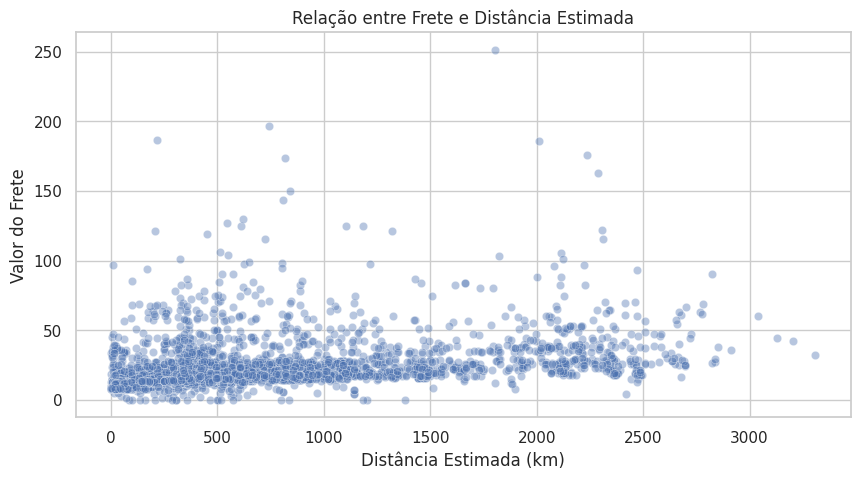

In [98]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_freight.sample(min(5000, len(df_freight)), random_state=42),
    x='distance_km',
    y='freight_value',
    alpha=0.4
)

plt.title('Relação entre Frete e Distância Estimada')
plt.xlabel('Distância Estimada (km)')
plt.ylabel('Valor do Frete')
plt.savefig('images/Relação entre Frete e DistÂncia Estimada.png', dpi=300)
plt.show()

## 💡 Insight — Relação entre Frete e Distância

A análise mostra tendência de aumento do frete com a distância, porém com alta dispersão.

Isso indica que a distância não é o único fator determinante do custo logístico.

### 📊 Implicações de Negócio

- O modelo de frete não é linear  
- Outros fatores influenciam o custo (peso, categoria, etc)  
- Oportunidade de otimização de precificação  

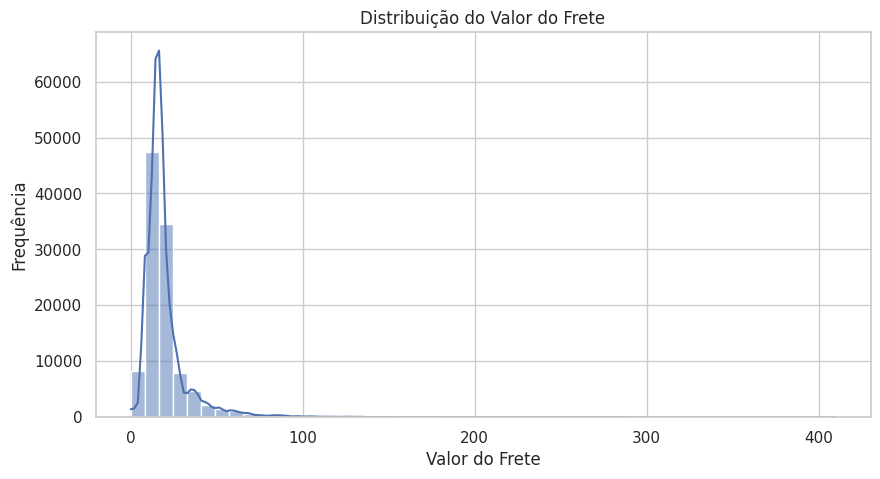

In [99]:
plt.figure(figsize=(10, 5))
sns.histplot(df_freight['freight_value'], bins=50, kde=True)

plt.title('Distribuição do Valor do Frete')
plt.xlabel('Valor do Frete')
plt.ylabel('Frequência')
plt.savefig('images/Distribuição do Valor do Frete.png', dpi=300)
plt.show()

In [100]:
df_freight[['distance_km', 'freight_value']].corr()

,distance_km,freight_value
distance_km,1.000000,0.391964
freight_value,0.391964,1.000000


## 💡 Insight — Distribuição do Valor do Frete

A maior parte dos pedidos apresenta valores de frete baixos a moderados, com poucos casos de frete elevado.

A presença de uma cauda longa indica situações específicas de alto custo logístico.

### 📊 Implicações de Negócio

- Frete geralmente acessível para a maioria dos clientes  
- Casos extremos podem impactar conversão  
- Possível necessidade de revisão de políticas de frete  

# 10. Conclusão Geral

## 🎯 Síntese do Projeto

Este projeto analisou dados operacionais da Olist com o objetivo de identificar padrões de demanda, eficiência logística e possíveis pontos de melhoria na operação de entregas.

Foram exploradas métricas fundamentais para negócios digitais, como volume de pedidos ao longo do dia, tempo de entrega por região, comportamento de atrasos e estrutura de custo logístico.

---

## 📊 Principais Aprendizados

A análise permitiu identificar padrões importantes:

- A demanda apresenta forte concentração entre 10h e 22h, indicando comportamento de consumo ao longo do período ativo do dia  
- Existe variação significativa no tempo de entrega entre os estados, refletindo diferenças na infraestrutura logística  
- A maior parte das entregas ocorre dentro de um padrão esperado, mas há uma cauda de atrasos extremos que pode impactar negativamente a experiência do cliente  
- O valor do frete apresenta relação com a distância, mas não de forma linear, indicando influência de múltiplos fatores  

---

## 🧠 Interpretação de Negócio

Os resultados mostram que, embora a operação funcione de forma eficiente na maioria dos casos, existem pontos críticos que merecem atenção:

- Regiões com maior tempo de entrega podem representar gargalos logísticos  
- Entregas fora do padrão (outliers) devem ser monitoradas e investigadas  
- O comportamento de demanda exige planejamento estratégico da operação ao longo do dia  
- O modelo de frete pode ser otimizado para maior eficiência e competitividade  

---

## 🚀 Aplicação Prática

Em um cenário real, esses insights poderiam ser utilizados para:

- Ajustar a alocação de recursos operacionais em horários de pico  
- Melhorar a previsão de prazos de entrega  
- Reduzir a incidência de atrasos extremos  
- Otimizar custos logísticos e políticas de frete  
- Apoiar decisões estratégicas baseadas em dados  

---

## 🔮 Próximos Passos

Como evolução do projeto, seria possível:

- Desenvolver modelos preditivos para antecipar atrasos  
- Analisar a relação entre tempo de entrega e satisfação do cliente  
- Investigar o impacto do frete na conversão de compras  
- Criar dashboards interativos para monitoramento em tempo real  